In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from numpy import cos,pi,sqrt,exp,log10
from astropy.table import Table
from astropy.table import unique
import os
import matplotlib.colors as mcolors
from astropy.io import ascii
import ctadata


In [2]:
Name='Crab'
coords_obj=SkyCoord.from_name(Name)
ra_obj=coords_obj.icrs.ra.deg
dec_obj=coords_obj.icrs.dec.deg
ra_obj,dec_obj
cdec=cos(dec_obj*pi/180.)
gheff='gheff0.9'
Zdcut=30

Radius=0.316

z=0.0001


In [3]:
Ebins=np.logspace(log10(0.05),log10(50),16)
Emins=Ebins[:-1]
Emaxs=Ebins[1:]
Emeans=sqrt(Emins*Emaxs)
dE=Emaxs-Emins
Nebins=len(Emeans)

th2bins=np.linspace(0,4,401)
th2=(th2bins[1:]+th2bins[:-1])/2.
Nth=len(th2)


In [4]:
run_catalog=ascii.read('LST_source_catalog.ecsv')
    
runlist=np.load('good_runs_'+Name+'_Zd_30.0.npy')
len(runlist)
runlist[0]


2692

In [5]:

fname='dl3_LST-1.Run03222.fits'
hdul=fits.open(fname)
hdu=hdul['ENERGY DISPERSION'].data
e_lo=hdu['ENERG_LO'][0]
e_hi=hdu['ENERG_HI'][0]
e_mid=sqrt(e_lo*e_hi)
de=e_hi-e_lo
th_lo=hdu['THETA_LO']
th_hi=hdu['THETA_HI']
migra_lo=hdu['MIGRA_LO'][0]
migra_hi=hdu['MIGRA_HI'][0]
migra=sqrt(migra_lo*migra_hi)
dmigra=migra_hi-migra_lo

Netruebins=len(e_mid)
Nmigra=len(migra)


In [6]:
flist=[]
counter=0

runs=[]
effareas=[]
texpos=np.array([])
cts_s=np.zeros((Nebins,Nth))
cts_b1=np.zeros((Nebins,Nth))
matrix=np.zeros((Nmigra,Netruebins))


for ind in range(100):#len(runlist)):
    r=runlist[ind]
    for i in range(len(run_catalog)):
        run=run_catalog[i]['Run ID']
        if(run==r):
            date=run_catalog[i]['Date directory'].replace('-','')
            vers=ctadata.list_dir('/pnfs/cta.cscs.ch/lst/DL3/'+date)
            for ver in vers:
                if(ver[0]=='v'):
                    tailcuts=ctadata.list_dir('/pnfs/cta.cscs.ch/lst/DL3/'+date+'/'+ver)
                    for tailcut in (tailcuts):
                        nsbs=ctadata.list_dir('/pnfs/cta.cscs.ch/lst/DL3/'+date+'/'+ver+'/'+tailcut)
                        for nsb in nsbs:
                            versions=(ctadata.list_dir('/pnfs/cta.cscs.ch/lst/DL3/'+date+'/'+ver+'/'+tailcut+'/'+nsb))
                            for version in versions:
                                tags=ctadata.list_dir('/pnfs/cta.cscs.ch/lst/DL3/'+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std')
                                for tag in tags:
                                    src_dependences=(ctadata.list_dir('/pnfs/cta.cscs.ch/lst/DL3/'+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std/'+tag))
                                    for src_dep in src_dependences:
                                        point_or_full=(ctadata.list_dir('/pnfs/cta.cscs.ch/lst/DL3/'+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std/'+tag+'/'+src_dep))
                                        for p_f in point_or_full:
                                            wobbles=(ctadata.list_dir('/pnfs/cta.cscs.ch/lst/DL3/'+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std/'+tag+'/'+src_dep+'/'+p_f))
                                            for wob in wobbles:
                                                gheffs=(ctadata.list_dir('/pnfs/cta.cscs.ch/lst/DL3/'+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std/'+tag+'/'+src_dep+'/'+p_f+'/'+wob))        
                                                for gh in gheffs:
                                                    if(gheff in gh):
                                                        irfs=(ctadata.list_dir('/pnfs/cta.cscs.ch/lst/DL3/'+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std/'+tag+'/'+src_dep+'/'+p_f+'/'+wob+'/'+gh))
                                                        for irf in irfs:
                                                            files=(ctadata.list_dir('/pnfs/cta.cscs.ch/lst/DL3/'+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std/'+tag+'/'+src_dep+'/'+p_f+'/'+wob+'/'+gh+'/'+irf))
                                                            if(run<10000):
                                                                fname='dl3_LST-1.Run0'+str(run)+'.fits'
                                                            else:
                                                                fname='dl3_LST-1.Run'+str(run)+'.fits'
                                                            if(fname in files):
                                                                flist.append('/pnfs/cta.cscs.ch/lst/DL3/'+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std/'+tag+'/'+src_dep+'/'+p_f+'/'+wob+'/'+gh+'/'+irf+'/'+fname)
                                                                f=('/pnfs/cta.cscs.ch/lst/DL3/'+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std/'+tag+'/'+src_dep+'/'+p_f+'/'+wob+'/'+gh+'/'+irf+'/'+fname)
                                                                counter+=1
                                                                ctadata.fetch_and_save_file_or_dir('/pnfs/cta.cscs.ch/lst/DL3/'+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std/'+tag+'/'+src_dep+'/'+p_f+'/'+wob+'/'+gh+'/'+irf+'/'+fname)
                                                                hdul=fits.open(fname)
                                                                header=hdul[1].header
                                                                print(counter,date,fname)
                                                                ra_pnt=header['RA_PNT']
                                                                dec_pnt=header['DEC_PNT'] 
                                                                dra=ra_obj-ra_pnt
                                                                ddec=dec_obj-dec_pnt
                                                        
                                                                ra_bkg1=ra_pnt-dra
                                                                dec_bkg1=dec_pnt-ddec
                                                                coords_bkg1=SkyCoord(ra_bkg1,dec_bkg1,unit='degree')
                                                                
                                                                events=hdul['EVENTS'].data
                                                                coords=SkyCoord(events['RA'],events['DEC'],unit='degree')
                                                        
                                                                seps=coords.separation(coords_obj).deg
                                                                seps_b1=coords_bkg1.separation(coords).deg
                                                        
                                                                energies=events['ENERGY']
                                                                for i in range(Nebins):
                                                                    m=(energies>Emins[i])*(energies<Emaxs[i])*(seps_b1>0.4)
                                                                    h=np.histogram(seps[m]**2,bins=th2bins)
                                                                    cts_s[i]+=h[0]
                                                                    m=(energies>Emins[i])*(energies<Emaxs[i])*(seps>0.4)
                                                                    h_b1=np.histogram(seps_b1[m]**2,bins=th2bins)
                                                                    cts_b1[i]+=h_b1[0]
                                                        
                                                        
                                                                hdu=hdul['ENERGY DISPERSION'].data
                                                                rms=hdu['MATRIX'][0][0] #probability to reconstruct energy migra*energy for true energy "energy"
                                                            
                                                                hdu=hdul['EFFECTIVE AREA'].data 
                                                                aeff=hdu['EFFAREA'][0][0]*1e4
                                                                header=hdul[1].header
                                                                texpos=header['LIVETIME']
                                                                expos=aeff*texpos
                                                                for i in range(Nmigra):
                                                                    for j in range(Netruebins):
                                                                        matrix[i,j]+=rms[i,j]*expos[j]
                                                                os.remove(fname)



1 20200913 dl3_LST-1.Run02692.fits
2 20201118 dl3_LST-1.Run02929.fits
3 20201118 dl3_LST-1.Run02930.fits
4 20201118 dl3_LST-1.Run02931.fits
5 20201118 dl3_LST-1.Run02932.fits
6 20201118 dl3_LST-1.Run02933.fits
7 20201118 dl3_LST-1.Run02934.fits
8 20201119 dl3_LST-1.Run02949.fits
9 20201119 dl3_LST-1.Run02950.fits
10 20201119 dl3_LST-1.Run02956.fits
11 20201120 dl3_LST-1.Run02967.fits
12 20201120 dl3_LST-1.Run02968.fits
13 20201120 dl3_LST-1.Run02969.fits
14 20201120 dl3_LST-1.Run02970.fits
15 20201120 dl3_LST-1.Run02971.fits
16 20201120 dl3_LST-1.Run02972.fits
17 20201120 dl3_LST-1.Run02973.fits
18 20201120 dl3_LST-1.Run02974.fits
19 20201120 dl3_LST-1.Run02975.fits
20 20201120 dl3_LST-1.Run02976.fits
21 20201120 dl3_LST-1.Run02977.fits
22 20201121 dl3_LST-1.Run02988.fits
23 20201121 dl3_LST-1.Run02989.fits
24 20201121 dl3_LST-1.Run02990.fits
25 20201121 dl3_LST-1.Run02991.fits
26 20201121 dl3_LST-1.Run02992.fits
27 20201122 dl3_LST-1.Run03004.fits
28 20201122 dl3_LST-1.Run03006.fits
2

In [15]:
redshifts=np.linspace(0,6,601)
redshifts=redshifts[1:]
ebl=np.genfromtxt('tau_saldana-lopez21.out')
ee=ebl[:,0]
bb=ebl[:,1:]

m=(redshifts<z)
ind=sum(m)
if(ind>0):
    z1=redshifts[ind-1]
    z2=redshifts[ind]
    frac=(z-z1)/(z2-z1)
    tau=bb[:,ind-1]+frac*(bb[:,ind]-bb[:,ind-1])
else:
    z1=0
    z2=redshifts[ind]
    frac=(z-z1)/(z2-z1)
    tau=frac*(bb[:,ind])
tau1=np.interp(e_mid,ee,tau)


(1e-12, 1e-10)

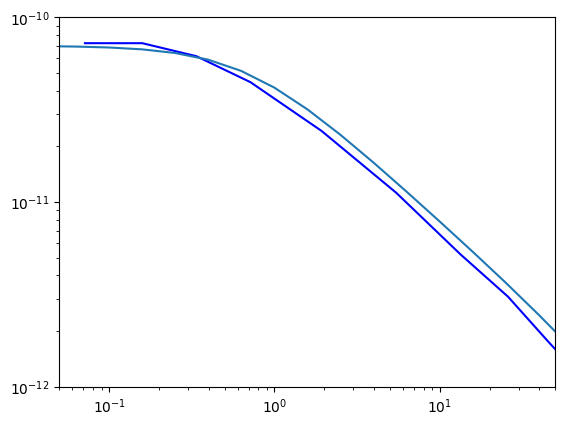

In [8]:
Gamma1=2.
Gamma2=2.82
Ebr=0.7
Norm=7.e-11

def dn_detrue(Norm,Gamma1,Gamma2,Ebr):
    return Norm*(e_mid/1)**(-Gamma1)/(1+(e_mid/Ebr)**1.6)**((Gamma2-Gamma1)/1.6)*exp(-tau1)

#reference spectrum:
d=np.genfromtxt('Crab_spectrum_fermi_lhaaso.csv')
plt.plot(d[:,0],d[:,1],color='blue',label='Crab')

plt.plot(e_mid,e_mid**2*dn_detrue(Norm,Gamma1,Gamma2,Ebr))
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.05,50)
plt.ylim(1e-12,1e-10)

In [9]:
def model_erec(Norm,Gamma1,Gamma2,Ebr):
    model=dn_detrue(Norm,Gamma1,Gamma2,Ebr)*de
    cts_rec=np.zeros(Nebins)
    for i in range(Netruebins):
        cts_migrated=model[i]*matrix[:,i]*dmigra
        e_rec=e_mid[i]*migra
        h=np.histogram(e_rec,weights=cts_migrated,bins=Ebins)
        cts_rec+=h[0]
    return cts_rec


In [10]:
spectrum=np.zeros(Nebins)
spectrum_err=np.zeros(Nebins)

0.04999999999999999 - 0.07924465962305566 : 27777.363636363618 +/- 2205.41356665819
0.07924465962305566 - 0.125594321575479 : 23955.11688311689 +/- 1455.5054105017955
0.125594321575479 - 0.19905358527674863 : 22373.038961038943 +/- 707.7330005023081
0.19905358527674863 - 0.3154786722400966 : 18473.376623376615 +/- 417.2205651690722
0.3154786722400966 - 0.49999999999999994 : 13664.259740259737 +/- 280.6047041658425
0.49999999999999994 - 0.7924465962305569 : 8836.623376623374 +/- 189.4887859478761
0.7924465962305569 - 1.2559432157547903 : 5039.103896103896 +/- 124.83188695201238
1.2559432157547903 - 1.9905358527674866 : 2869.8831168831152 +/- 80.88881257627658
1.9905358527674866 - 3.154786722400966 : 1296.7532467532476 +/- 52.16320542297991
3.154786722400966 - 4.999999999999999 : 600.2727272727277 +/- 34.307433596816885
4.999999999999999 - 7.92446596230557 : 299.5194805194803 +/- 23.280893453645632
7.92446596230557 - 12.559432157547908 : 121.2337662337662 +/- 15.198684153570664
12.559432

1.428571428571427

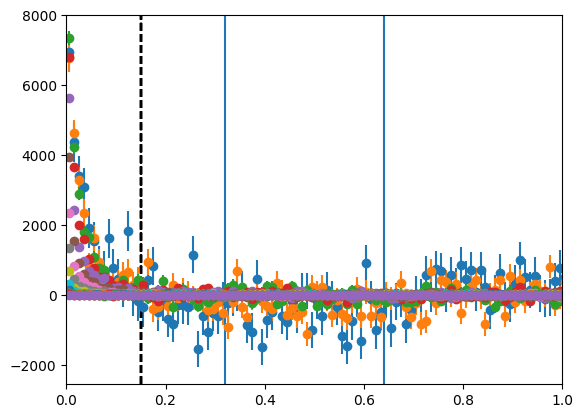

In [11]:
for i in range(Nebins):
    s_err=sqrt(cts_s[i]+cts_b1[i])
    s=cts_s[i]-cts_b1[i]
    plt.errorbar(th2,s,s_err,linestyle='none',marker='o')
    
    #plt.yscale('log')
    th2limit=0.15
    plt.axvline(th2limit,color='black',linestyle='dashed')
    bkg=sum(s[th2>th2limit])/sum(th2>th2limit)
    plt.axhline(bkg,color='black')
    spectrum[i]=sum(s[th2<th2limit]-bkg)
    spectrum_err[i]=sqrt(sum(s_err[th2<th2limit]**2))
    print(Emins[i],'-',Emaxs[i],':',spectrum[i],'+/-',spectrum_err[i])
plt.xlim(0,1)
plt.axvline(0.32)
plt.axvline(0.64)
sum(s[th2<th2limit]-bkg)


In [12]:
step=1.01
chisq_best=1e10
chisq=sum((spectrum-model_erec(Norm,Gamma1,Gamma2,Ebr))**2/spectrum_err**2)
print(chisq)
while(chisq<chisq_best):
    chisq_best=chisq
    chisq1=sum((spectrum-model_erec(Norm*step,Gamma1,Gamma2,Ebr))**2/spectrum_err**2)
    chisq2=sum((spectrum-model_erec(Norm/step,Gamma1,Gamma2,Ebr))**2/spectrum_err**2)
    chisq3=sum((spectrum-model_erec(Norm,Gamma1,Gamma2,Ebr*step))**2/spectrum_err**2)
    chisq4=sum((spectrum-model_erec(Norm,Gamma1,Gamma2,Ebr/step))**2/spectrum_err**2)
    chisq5=sum((spectrum-model_erec(Norm,Gamma1*step,Gamma2,Ebr))**2/spectrum_err**2)
    chisq6=sum((spectrum-model_erec(Norm,Gamma1/step,Gamma2,Ebr))**2/spectrum_err**2)
    chisq7=sum((spectrum-model_erec(Norm,Gamma1,Gamma2*step,Ebr))**2/spectrum_err**2)
    chisq8=sum((spectrum-model_erec(Norm,Gamma1,Gamma2/step,Ebr))**2/spectrum_err**2)
    chisq_vec=np.array([chisq1,chisq2,chisq3,chisq4,chisq5,chisq6,chisq7,chisq8])
    ind=np.argmin(chisq_vec)
    if(min(chisq_vec)<chisq_best):
        if(ind==0):
            chisq=chisq1
            Norm*=step
        if(ind==1):
            chisq=chisq2
            Norm/=step
        if(ind==2):
            chisq=chisq3
            Ebr*=step
        if(ind==3):
            chisq=chisq4
            Ebr/=step
        if(ind==4):
            chisq=chisq5
            Gamma1*=step
        if(ind==5):
            chisq=chisq6
            Gamma1/=step
        if(ind==6):
            chisq=chisq7
            Gamma2*=step
        if(ind==7):
            chisq=chisq8
            Gamma2/=step
    print(chisq,Norm,Ebr,Gamma1,Gamma2)


438.6269718492108
370.6865830067762 7e-11 0.7 2.02 2.82
310.2209407635607 7e-11 0.7 2.0402 2.82
258.44515878534463 7e-11 0.7 2.060602 2.82
213.77244217885922 7e-11 0.7 2.060602 2.792079207920792
174.47059012922412 7e-11 0.7 2.060602 2.7644348593275168
138.71723674907287 7e-11 0.7 2.08120802 2.7644348593275168
108.58424511608655 7e-11 0.7 2.08120802 2.7370642171559574
85.20332308122424 7e-11 0.7 2.08120802 2.709964571441542
68.56558568775122 7e-11 0.7 2.1020201002 2.709964571441542
56.46256346602643 7e-11 0.7 2.1020201002 2.6831332390510316
51.26758844719203 7.07e-11 0.7 2.1020201002 2.6831332390510316
48.31447751514442 7.1407e-11 0.7 2.1020201002 2.6831332390510316
47.37036038232115 7.1407e-11 0.707 2.1020201002 2.6831332390510316
46.634826477153574 7.1407e-11 0.71407 2.1020201002 2.6831332390510316
46.107672592977636 7.1407e-11 0.7212107 2.1020201002 2.6831332390510316
45.788680226561425 7.1407e-11 0.728422807 2.1020201002 2.6831332390510316
44.99064934974266 7.1407e-11 0.728422807 2.

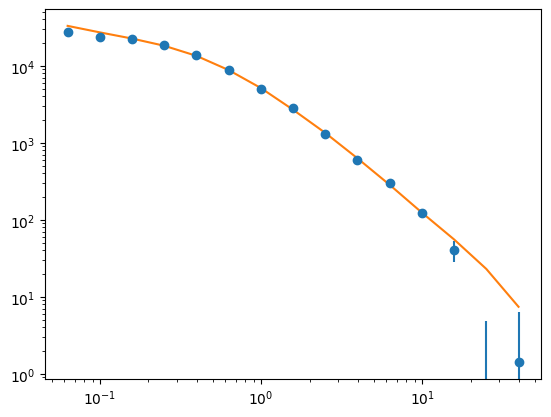

In [13]:
plt.errorbar(Emeans,spectrum,spectrum_err,marker='o',linestyle='none')

plt.plot(Emeans,model_erec(Norm,Gamma1,Gamma2,Ebr))
plt.xscale('log')
plt.yscale('log')

(1e-12, 1e-10)

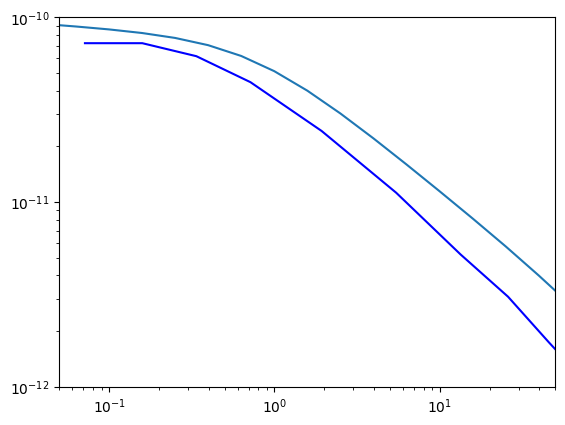

In [14]:
#reference spectrum:
d=np.genfromtxt('Crab_spectrum_fermi_lhaaso.csv')
plt.plot(d[:,0],d[:,1],color='blue',label='Crab')

plt.plot(e_mid,e_mid**2*dn_detrue(Norm,Gamma1,Gamma2,Ebr))
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.05,50)
plt.ylim(1e-12,1e-10)